In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
src_path = os.path.abspath('src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import *

1. Data preparation

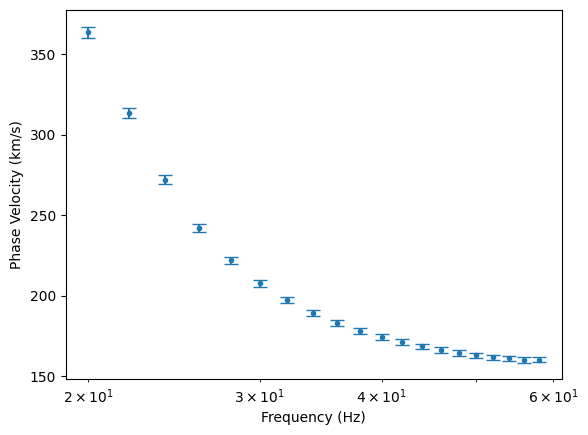

In [2]:
# Load fundamental-model R-wave dispersion data, units are Hz and m/s
data = np.loadtxt(r'examples\example_01.txt')
f = data[:,0]
vr = data[:,1]
vr_std = data[:,2] # you can specify the standard deviation yourself if not provided

# Sort the dispersion data from smallest to largest frequency
sorted_indices = np.argsort(f)
f = f[sorted_indices]
vr = vr[sorted_indices]
vr_std = vr_std[sorted_indices]

# Visualize the dispersion data
plt.errorbar(f, vr, yerr=vr_std, fmt='o', markersize=3, capsize=5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase Velocity (km/s)')
plt.xscale('log')

2. Dispersion curve normalization

In [3]:
# Estimate halfspace depth and S-wave velocity bounds
vs_bounds_halfspace = np.array([1.07*np.max(vr),3*np.max(vr)])
depth_bounds_halfspace = np.array([0.2, 1])*np.max(vr/f)
print('vs_bounds_halfspace (m/s):', vs_bounds_halfspace)
print('depth_bounds_halfspace (m):', depth_bounds_halfspace)

# Normalization and resampling
depth_scalers, vs_scalers, f_vr_resampled = scale_and_resample_dc(f, vr, vs_bounds_halfspace, depth_bounds_halfspace, 
                                                          nd = 400, nv = 400, v_scale='log', d_scale='log')
f_vr_resampled = np.array(f_vr_resampled, dtype=object)

vs_bounds_halfspace (m/s): [ 388.81641061 1090.139469  ]
depth_bounds_halfspace (m): [ 3.63379823 18.16899115]


3. Inversion

In [ ]:
model_path = r"models\PADIT.pth"  # model path
scaler_path = r"models\PADIT.pkl"  # scaler path
vs_predict = run_prediction(model_path, scaler_path, f_vr_resampled)

Using device: cuda
Input data: 160000 samples
Loading scalers...
Loading model...
Model parameters: 2,115,204
Preprocessing data...
Starting prediction...


Prediction Progress: 100%|██████████| 160000/160000 [00:08<00:00, 19429.31it/s]


Prediction complete!
Final result shape: (160000, 100)


4. Denormalization

In [5]:
# Each row of thickness_inverted and vs_predict corresponds to a predicted S-wave velocity profile
# The last column of thickness_inverted is the thickness of the halfspace, the values do not matter
vs_predict = np.hstack((vs_predict, np.full((vs_predict.shape[0], 1), 1000)))
thickness_inverted, vs_inverted = denormalize_dc(vs_predict, depth_scalers, vs_scalers)

5. Forward computation

In [6]:
# Forward computation with parallel processing
# Note: Using n_jobs=-1 will utilize all CPU cores and may cause your computer to become slow or unresponsive.
# If you do not want to use all cores, change the n_jobs parameter to a smaller value (e.g., n_jobs=4).
f_scaled = vs_scalers.reshape(-1, 1) /depth_scalers.reshape(-1, 1) * f.reshape(1, -1)
vr_inverted = forward_parallel(vs_predict, f_scaled, n_jobs=-1)
vr_inverted = vr_inverted / vs_scalers.reshape(-1, 1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 260 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 3700 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 9300 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 16500 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done 25300 tasks      | elapsed:   28.6s
[Parallel(n_jobs=-1)]: Done 35700 tasks      | elapsed:   37.9s
[Parallel(n_jobs=-1)]: Done 47700 tasks      | elapsed:   48.0s
[Parallel(n_jobs=-1)]: Done 61300 tasks      | elapsed:   59.3s
[Parallel(n_jobs=-1)]: Done 76500 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 93300 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 111700 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 131700 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 153300 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 16

6. Evalualte

In [7]:
# Find qualified models and rank them based on the misfit
qualified_indices, vr_misfit = find_qualified_indices_and_rank(vr, vr_std, vr_inverted)
print(f"Number of qualified models: {len(qualified_indices)}")
thickness_qualified = thickness_inverted[qualified_indices]
vs_qualified = vs_inverted[qualified_indices]
vr_qualified = vr_inverted[qualified_indices]

Number of qualified models: 17561


7. Plot

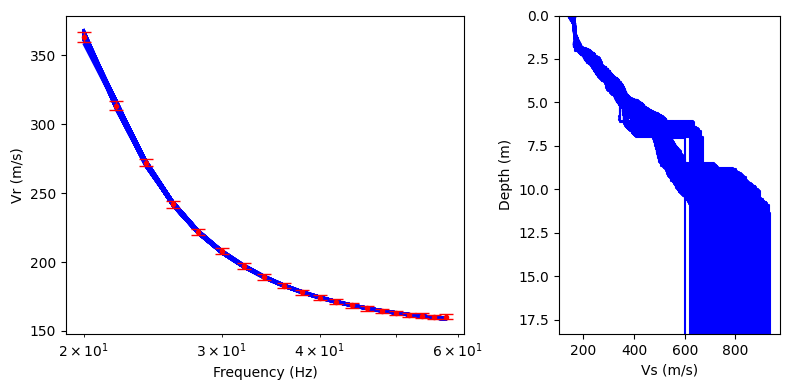

In [8]:
# Select the number of models to plot, starting from the best-ranked model
plot_number = 1000

fig, axs = plt.subplots(1, 2, 
                        figsize=(8, 4), 
                        gridspec_kw={'width_ratios': [1.8, 1]})

for i in range(plot_number):
    axs[0].plot(f, vr_qualified[i], 'b-')
axs[0].errorbar(f,vr, yerr=vr_std.reshape(-1), fmt='o', ecolor='red', elinewidth=1, markersize=3,capsize=5,color = 'red')
axs[0].set_xscale('log')
axs[0].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Vr (m/s)')

depth_plot = get_depth_for_plot(thickness_qualified)
vs_plot = np.repeat(vs_qualified,2,axis=1)
for i in range(plot_number):
    axs[1].plot(vs_plot[i],depth_plot[i],color = 'blue')
axs[1].set_ylim(0, np.max(depth_plot))
axs[1].set_xlabel('Vs (m/s)')
axs[1].set_ylabel('Depth (m)')
axs[1].invert_yaxis()
plt.tight_layout()